# Data Exploration

## Imports and Connection

In [1]:
# Imports
import os
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from dotenv import load_dotenv

In [2]:
# Searches for .env
load_dotenv()

# Get database information
user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_DATABASE")

# Initialize SQL engine
engine = create_engine(
    f"mysql+mysqlconnector://{user}:{password}@{host}:{port}/{database}",
    connect_args={"connection_timeout": 5}
)

def run(query):
    return pd.read_sql(query, con=engine)

try:
    result = run("SELECT 1 AS connected")
    print(f"Success {result.iloc[0,0]}")
except Exception as e:
    print(f"Connection failed.")

Success 1


## Database Information

### Show Tables and Views

In [3]:
def show_tables(table_type):
    names = {"BASE TABLE": "table_name", 
             "VIEW": "view_name"}

    if table_type not in names:
        raise ValueError("Table type must be 'BASE TABLE' or 'VIEW'.")

    query = f"""
    SHOW FULL TABLES
    WHERE Table_type = '{table_type}';
    """

    return run(query).iloc[:, 0].rename(names[table_type])

tables = show_tables("BASE TABLE")
views = show_tables("VIEW")

display(tables)
display(views)

0                  items
1     order_history_hdrs
2    order_history_lines
3        po_history_hdrs
4       po_history_lines
5               vmi_tags
Name: table_name, dtype: object

0            current_inventory
1                  items_clean
2     order_history_hdrs_clean
3    order_history_lines_clean
4        po_history_hdrs_clean
5       po_history_lines_clean
6           po_to_sales_margin
7                vmitags_clean
8         ytd_profit_per_class
Name: view_name, dtype: object

### DataFrame Creation

In [4]:
all_dfs = {}

def create_dfs(table_type):
    if table_type == "BASE TABLE":
        items = tables
    elif table_type == "VIEW":
        items = views
    else:
        raise ValueError("table_type must be 'BASE TABLE' or 'VIEW'.")

    for item in items:
        if item not in all_dfs:
            all_dfs[item] = run(f"SELECT * FROM `{item}`")

create_dfs("BASE TABLE")
create_dfs("VIEW")

# Make all dataframes accessible as individual variables
items_clean_df = all_dfs["items_clean"]
order_history_hdrs_clean_df = all_dfs["order_history_hdrs_clean"]
order_history_lines_clean_df = all_dfs["order_history_lines_clean"]
po_history_hdrs_clean_df = all_dfs["po_history_hdrs_clean"]
po_history_lines_clean_df = all_dfs["po_history_lines_clean"]
vmitags_clean_df = all_dfs["vmitags_clean"]


In [14]:
# Make all dataframes accessible as individual variables

current_inventory_df = all_dfs["current_inventory"]
total_inv_df = all_dfs["po_to_sales_margin"]

### Create Full CSVs

In [5]:
# Convert tables to CSV

# for table in tables["Tables_in_profitssql"]:
#     q = f"Select * from `{table}`;"
#     globals()[f"{table}_df"] = run(q)
#     globals()[f"{table}_df"].to_csv(f"{table}.csv", index=False)

### Create Cleaned CSVs

In [6]:
from pathlib import Path

output_folder = Path("../../../data")
output_folder.mkdir(parents=True, exist_ok=True)

for view in views:
    if view == "ytd_profit_per_class":
        continue

    output_file = output_folder / f"{view}.csv"

    run(f"SELECT * FROM `{view}`").to_csv(output_file, index=False)

print(f"Last run: {pd.Timestamp.now():%Y-%m-%d %H:%M:%S}")

Last run: 2026-10-09 11:59:39


### Descriptions

In [7]:
# for table in tables["Tables_in_profitssql"]:
#     q = f"DESCRIBE `{table}`;"
#     display(run(q))a

### Dimensions

In [8]:
catalog_query = """
SELECT TABLE_NAME AS name, TABLE_TYPE AS table_type
FROM information_schema.tables
WHERE table_schema = DATABASE()
ORDER BY table_name;
"""
catalog = run(catalog_query)

summary_rows = []

for _, entry in catalog.iterrows():
    name = entry["name"]
    table_type = entry["table_type"]

    column_count = run(
        f"SELECT COUNT(*) FROM information_schema.columns "
        f"WHERE table_schema = DATABASE() AND table_name = '{name}'"
    ).squeeze()

    row_count = run(f"SELECT COUNT(*) FROM `{name}`").squeeze()

    summary_rows.append({
        "name": name,
        "table_type": table_type,
        "columns": column_count,
        "rows": row_count,
    })

table_summary = pd.DataFrame(summary_rows)

### Data Recency

In [9]:
query = "select max(item_lsale) as 'Last Sale' from items"

lsale = pd.to_datetime(run(query).squeeze())
print(lsale.strftime("%Y-%m-%d"))
print(f"Days since: {(pd.Timestamp.now().normalize() - lsale).days}")

2026-10-08
Days since: 1


## External Research
### Simple Price Chart

[*********************100%***********************]  1 of 1 completed


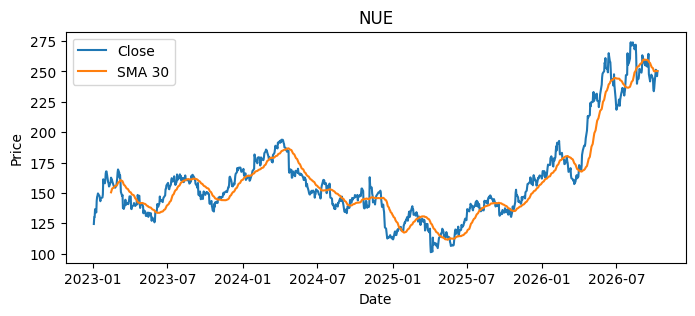

In [18]:
import yfinance as yf
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

ticker = 'NUE'

df = yf.download(ticker, start='2023-01-01', end=dt.datetime.today(), auto_adjust=True)

df = df['Close'].squeeze().rename('Close').reset_index().round(2)
df['Date'] = pd.to_datetime(df['Date'])
sma_30 = df['Close'].rolling(window=30).mean()

plt.figure(figsize=(8,3))
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], sma_30, label='SMA 30')
plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'{ticker}')
plt.legend()
plt.show()

In [ ]:
# Add two numbers
a = 8
b = 9

print(f"Sum: {a+b}")



Sum: 17
hello jack


### Auction Theory
#### Bid Shading
First Order Condition Formula

--- First-Price Sealed-Bid FOC Simulation (5 Bidders) ---
Valuation (s): $ 9.18 | Optimal Bid (b): $ 7.35 | Shade Amount: $ 1.84
Valuation (s): $29.36 | Optimal Bid (b): $23.49 | Shade Amount: $ 5.87
Valuation (s): $49.55 | Optimal Bid (b): $39.64 | Shade Amount: $ 9.91
Valuation (s): $69.73 | Optimal Bid (b): $55.78 | Shade Amount: $13.95
Valuation (s): $89.91 | Optimal Bid (b): $71.93 | Shade Amount: $17.98


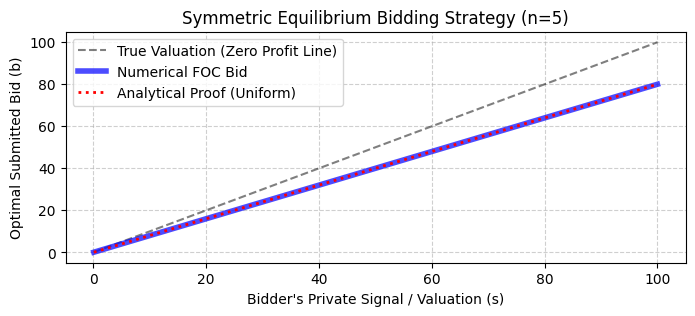

In [11]:
import numpy as np
from scipy import integrate
import scipy.stats as stats
import matplotlib.pyplot as plt

def first_price_bid(s, n, cdf_func, s_min):
    """
    Calculates the symmetric equilibrium bid in a first-price sealed-bid auction 
    using the First Order Condition continuous formula.
    
    Parameters:
    s (float): Bidder's private valuation (signal)
    n (int): Total number of bidders
    cdf_func (callable): Cumulative Distribution Function of the valuations, F(s)
    s_min (float): The lowest possible valuation in the support (s lower bar)
    """
    if s <= s_min:
        return s_min
        
    # Denominator: F(s)^(n-1)
    F_s = cdf_func(s)
    if F_s == 0:
        return s
    denominator = F_s ** (n - 1)
    
    # Numerator Integral: integral from s_min to s of F(x)^(n-1) dx
    def integrand(x):
        return cdf_func(x) ** (n - 1)
        
    integral_val, _ = integrate.quad(integrand, s_min, s)
    
    # FOC Equilibrium Bid Formula
    b_s = s - (integral_val / denominator)
    return b_s

# --- Configuration ---
n_bidders = 5
s_min = 0
s_max = 100

# Define the environment's probability distribution (Uniform used here as baseline)
distribution = stats.uniform(loc=s_min, scale=s_max - s_min)

# Generate an array of possible simulated valuations
valuations = np.linspace(s_min + 0.1, s_max, 100)

# Calculate numerical bids using the FOC integration
numerical_bids = [first_price_bid(s, n_bidders, distribution.cdf, s_min) for s in valuations]

# For a Uniform distribution, the analytical known solution is exactly: b(s) = s * (n-1)/n
# We calculate this to prove the numerical integral logic is flawlessly matching theory
analytical_bids = valuations * ((n_bidders - 1) / n_bidders)

# --- Console Output ---
print(f"--- First-Price Sealed-Bid FOC Simulation ({n_bidders} Bidders) ---")
for val, bid in zip(valuations[9::20], numerical_bids[9::20]):
    print(f"Valuation (s): ${val:5.2f} | Optimal Bid (b): ${bid:5.2f} | Shade Amount: ${val-bid:5.2f}")

# --- Visualization ---
plt.figure(figsize=(8, 3))
plt.plot(valuations, valuations, 'k--', alpha=0.5, label="True Valuation (Zero Profit Line)")
plt.plot(valuations, numerical_bids, 'b-', linewidth=4, alpha=0.7, label="Numerical FOC Bid")
plt.plot(valuations, analytical_bids, 'r:', linewidth=2, label="Analytical Proof (Uniform)")

plt.title(f"Symmetric Equilibrium Bidding Strategy (n={n_bidders})")
plt.xlabel("Bidder's Private Signal / Valuation (s)")
plt.ylabel("Optimal Submitted Bid (b)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Markov Chains

In [12]:
import numpy as np

s_names = ["Hot", "Cold", "Rain"]
v_0 = np.array([0.4, 0.25, 0.35])

P = np.array([[0.4, 0.5, 0.1],
              [0.1, 0.6, 0.3],
              [0.2, 0.2, 0.6]])

# Initialize list and manually calculate x_1 so we have two items to compare
states = [v_0]
states.append(states[-1] @ P) 
print(f"x_1: {states[-1]}")

# Check if the maximum absolute difference is GREATER than e
e = 0.001
i = 1
while np.max(np.abs(states[-1] - states[-2])) > e:
    next_state = states[-1] @ P
    states.append(next_state)
    i += 1

print(f"Initial State: {states[0]}")
print(f"Steady State: {np.round(states[-1],2)}")


# Probability of it being Hot, Rain, Rain, Cold
prob_sequence = (
    v_0[s_names.index("Hot")]
    * P[s_names.index("Hot"), s_names.index("Rain")]
    * P[s_names.index("Rain"), s_names.index("Rain")]
    * P[s_names.index("Rain"), s_names.index("Cold")]
)
print(f"Probability of the sequence Hot, Rain, Rain, Cold: {round(prob_sequence, 3)}")



import random as rand

def prob_of_seq(seq, v_0, P, s_names):
    prob = v_0[s_names.index(seq[0])]
    for i in range(1, len(seq)):
        prob *= P[s_names.index(seq[i-1]), s_names.index(seq[i])]
    return prob


n = rand.randint(1, 10)
seq_list = []
for i in range(n):
    seq_list.append(s_names[rand.randint(0, len(s_names)-1)])

print(f"Probability of sequence {seq_list}: {round(prob_of_seq(seq_list, v_0, P, s_names), 4)}")



x_1: [0.255 0.42  0.325]
Initial State: [0.4  0.25 0.35]
Steady State: [0.2  0.43 0.37]
Probability of the sequence Hot, Rain, Rain, Cold: 0.005
Probability of sequence ['Rain', 'Cold', 'Hot', 'Hot', 'Hot', 'Rain', 'Rain']: 0.0001


## Win Probabilities

In [13]:
# Need to work on this estimation
mills_num = 6
total_coils_per_sheet = 300
alpha = 0.75
avail_coils_per_week = alpha * total_coils_per_sheet
weeks_in_yr = 40

total_avail_coils_per_year = avail_coils_per_week * weeks_in_yr
print(f"Total estimated available coils to bid on per year: {total_avail_coils_per_year}")


dates = pd.to_datetime(po_history_lines_clean_df["POLN_DATE_GOODS_RECD"], errors="coerce")

year = 2025

yearly_total = (
    dates.notna()
    & (dates >= f"{year}-01-01")
    & (dates < f"{year + 1}-01-01")
).sum()


print(f"Total items bought in {year}: {yearly_total}")

est_win_prob = ((total_avail_coils_per_year / yearly_total)*100).round(2)


est_win_prob



Total estimated available coils to bid on per year: 9000.0


KeyError: 'POLN_DATE_GOODS_RECD'

## Inventory

_______
Inventory Level at a Point in Time

For product $i$, choose a known inventory snapshot at time $t_0$. For any later time $t$:

$$Q_i(t) = Q_i(t_0) + \sum_{t_0 < \tau \le t} R_i(\tau) + \sum_{t_0 < \tau \le t} C_i(\tau) + \sum_{t_0 < \tau \le t} A_i(\tau) - \sum_{t_0 < \tau \le t} S_i(\tau)$$

where:

- $Q_i(t)$ = on-hand quantity of product $i$ at time $t$
- $R_i(\tau)$ = purchase receipts at transaction time $\tau$
- $C_i(\tau)$ = customer returns received at transaction time $\tau$
- $A_i(\tau)$ = signed adjustments and net transfers at transaction time $\tau$
- $S_i(\tau)$ = shipped quantity at transaction time $\tau$

Use receipt and shipment dates, not order dates. Returns and adjustments must be signed consistently: additions are positive and removals are negative.

_____
Available Inventory

$$\text{Available}_i(t) = Q_i(t) - \text{Allocated}_i(t) - \text{Hold}_i(t)$$

Open purchase orders are not on-hand inventory. If useful for planning, calculate projected inventory separately:

$$\text{Projected}_i(t) = \text{Available}_i(t) + \text{Expected Receipts}_i(t) - \text{Expected Demand}_i(t)$$

____
Inventory Value

$$V_i(t) = Q_i(t) \times \text{Unit Cost}_i(t)$$

For total inventory value at time $t$:

$$V(t) = \sum_i Q_i(t) \times \text{Unit Cost}_i(t)$$

Use the same costing method throughout, such as weighted-average, FIFO, or standard cost. Exact historical inventory requires a dated opening snapshot and complete dated movements; current totals alone cannot reconstruct past inventory.

____
Turnover

$$\text{Inventory Turnover} = \frac{\text{COGS}}{\text{Average Inventory Cost}}$$

$$\text{Average Inventory Cost} = \frac{\text{Beginning Inventory Cost} + \text{Ending Inventory Cost}}{2}$$

$$\text{Days on Hand} = \frac{365}{\text{Inventory Turnover}}$$

Use cost, rather than sales revenue, for both COGS and inventory valuation. When monthly inventory snapshots are available, use their average instead of only the beginning and ending balances.

In [15]:
total_inv_df.head()

,vmitf_key,vmit_item_class_no,vmit_item_class_name,vmit_item_no,vmit_tag_desc,vmit_parent_tag_no,vmit_org_tag_no,vmit_is_org,vmit_is_child,vmit_is_dir_child_of_org,...,vmit_bin_loc,vmit_hardness,vmit_grade,vmit_surface,vmit_coating_wgt,vmit_piece_cnt,vmit_yield,vmit_tensile,vmit_elongation,vmit_defect
0,0001020,61,GALV,61240000COIL,GALV .023 X 48.125 X COIL,1020,1020,1,0,0,...,GRNPNT,None,None,None,0.0,0,0.0,0.0,0.0,None
1,0001021,61,GALV,61240000COIL,GALV .023 X 56.000 X COIL,1021,1021,1,0,0,...,GRNPNT,None,None,None,0.0,0,0.0,0.0,0.0,None
2,0001022,61,GALV,61300000COIL,GALV .014 X 56.000 X COIL,1022,1022,1,0,0,...,ELKGRV,None,None,None,0.0,0,0.0,0.0,0.0,None
3,0001033,61,GALV,61180000COIL,"GALV .046 X 4.035"" X COIL",1033,1033,1,0,0,...,GRNPNT,None,None,None,0.0,0,0.0,0.0,0.0,None
4,0001034,62,GLVN,62140000COIL,"GLVN .070 X 3.500"" X COIL",1034,1034,1,0,0,...,GRNPNT,None,None,None,0.0,0,0.0,0.0,0.0,None


## Profit
___
Gross Profit Margin

**Gross profit** is the dollar amount left after subtracting the cost of goods sold (COGS) from net sales revenue. **Gross profit margin** expresses that amount as a percentage of net sales revenue.

$$\text{Net Sales Revenue} = \text{Gross Sales} - \text{Discounts} - \text{Returns and Allowances}$$

$$\text{Gross Profit} = \text{Net Sales Revenue} - \text{COGS}$$

$$\text{Gross Profit Margin (\%)} = \frac{\text{Net Sales Revenue} - \text{COGS}}{\text{Net Sales Revenue}} \times 100$$

COGS is the recorded cost of the material actually sold during the same period. Purchases of material still in inventory are not yet COGS. Which freight and processing costs belong in inventory/COGS depends on the company's accounting treatment; document that treatment and avoid counting a cost twice.

____
Applying This to the Project 

For eligible sales lines $i$, define $R_i$ as net revenue and $C_i$ as the corresponding COGS:

$$G_i = R_i - C_i, \qquad \text{Line Margin}_i = \frac{G_i}{R_i} \times 100$$

Use extended line totals directly; do not multiply them by quantity again. Verify the pricing unit before using unit prices: dollars per pound, per hundredweight, per ton, and per coil are different bases.

### Total or Product-Class Gross Margin

For a product class, customer, or reporting period, **sum the dollar amounts first**, then divide:

$$\text{Group Gross Profit} = \sum_i R_i - \sum_i C_i$$

$$\text{Group Gross Margin (\%)} = \frac{\sum_i R_i - \sum_i C_i}{\sum_i R_i} \times 100$$

Do not take a simple average of line margins: small and large sales should not receive equal weight. For example, sales of 100 dollars at 50% margin and 900 dollars at 10% margin produce total gross profit of 140 dollars on 1,000 dollars of revenue: **14% overall margin**, not 30%.

### Markup vs. Margin

**Markup** measures profit relative to cost; **margin** measures profit relative to revenue.

$$\text{Markup (\%)} = \frac{\text{Gross Profit}}{\text{COGS}} \times 100$$

In the coil example, markup is $3{,}000 / 9{,}000 \times 100 = 33.33\%$, while margin is 25%.

If $m$ is margin and $u$ is markup, both written as decimals:

$$m = \frac{u}{1+u}, \qquad u = \frac{m}{1-m}$$

For cost $C$ and a target gross margin $m$, with $0 \le m < 1$:

$$\text{Required Net Selling Price} = \frac{C}{1-m}$$

At a cost of 9,000 dollars and a target margin of 25%, the required net selling price is $9{,}000 / 0.75 = 12{,}000$ dollars. Multiplying cost by 1.25 instead sets a 25% markup, which produces only a 20% margin.

### Gross Profit per Pound

For metals sold at different weights, profit per pound helps compare dollar earnings on a common physical basis:

$$\text{Gross Profit per lb} = \frac{\text{Gross Profit}}{\text{Corresponding Sold Weight in lb}}$$

A 20,000-pound coil earning 3,000 dollars of gross profit generates $0.15$ dollars per pound. For a group of sales, divide total gross profit by total corresponding sold weight. Use actual sold weight, not unsold inventory or purchased weight, and convert units consistently.

### Contribution Profit and Break-Even

**Contribution profit** is net sales revenue minus **all variable costs** associated with those sales. It measures the amount available to cover fixed costs and then generate operating profit.

$$\text{Contribution Profit} = \text{Net Sales Revenue} - \text{Total Variable Costs}$$

$$\text{Contribution Margin (\%)} = \frac{\text{Contribution Profit}}{\text{Net Sales Revenue}} \times 100$$

Variable costs may include material, variable processing, delivery, and commissions. Include each cost once. Contribution profit equals gross profit minus other variable costs only when all COGS is variable and no other variable costs are already included in COGS.

If net selling price per pound is $p$, variable cost per pound is $v$, and fixed costs for the period are $F$:

$$\text{Break-Even Sold Weight (lb)} = \frac{F}{p-v}, \qquad p > v$$

This assumes constant unit prices and costs within the relevant volume range. A mix of products requires an assumed sales mix and a corresponding average contribution per pound.

____
Operating Profit and Net Profit

**Operating profit** subtracts operating expenses, such as administrative payroll and office expenses, from gross profit. Use expenses not already included in COGS.

$$\text{Operating Profit} = \text{Gross Profit} - \text{Operating Expenses}$$

$$\text{Operating Margin (\%)} = \frac{\text{Operating Profit}}{\text{Net Sales Revenue}} \times 100$$

**Net profit** also reflects financing, taxes, and other nonoperating items:

$$\text{Net Profit} = \text{Operating Profit} + \text{Nonoperating Income} - \text{Nonoperating Expenses} - \text{Income Tax Expense}$$

$$\text{Net Profit Margin (\%)} = \frac{\text{Net Profit}}{\text{Net Sales Revenue}} \times 100$$

Interest expense is an example of a nonoperating expense. Sales-line revenue and cost alone are insufficient to calculate operating or net profit.